# DNN DDoS Detection

## 0. Importing Libraries

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## 1. Data Preprocessing

In [70]:
df = pd.read_csv(Path().cwd() / 'data' / 'Dataset.csv')
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,target
0,185.127.17.56-192.168.20.133-443-53648-6,185.127.17.56,443,192.168.20.133,53648,6,5/2/2020 13:58,245230,44,40,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,185.127.17.56-192.168.20.133-443-53650-6,192.168.20.133,53650,185.127.17.56,443,6,5/2/2020 13:58,1605449,107,149,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.133,35108,192.168.20.2,53,6,5/2/2020 13:58,53078,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.2,53,192.168.20.133,35108,6,5/2/2020 13:58,6975,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,154.59.122.74-192.168.20.133-443-60900-6,192.168.20.133,60900,154.59.122.74,443,6,5/2/2020 13:58,190141,13,16,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [71]:
print(df.shape)
print(df['target'].value_counts(normalize=True))

(343889, 84)
target
1    0.801029
0    0.198971
Name: proportion, dtype: float64


In [73]:
print("Duplikati:", df.duplicated().sum())
print("NaN vrednosti ukupno:", df.isnull().sum().sum())

Duplikati: 1
NaN vrednosti ukupno: 0


In [74]:
#izbacivanje identifikatora
df.drop(columns=['Flow ID', 'Src IP', 'Dst IP', 'Timestamp'], inplace=True)
df.shape

(343889, 80)

In [75]:
print("Duplikatai nakon uklanjanja identifikatora:", df.duplicated().sum())

Duplikatai nakon uklanjanja identifikatora: 120517


In [76]:
#distribucija targeta kod duplikata
dup_mask = df.duplicated(keep=False)  # keep=False označava SVE kopije

print("Target distribucija among duplicated rows:")
print(df.loc[dup_mask, 'target'].value_counts(normalize=True))

print("\nTarget distribucija among unique rows:")
print(df.loc[~dup_mask, 'target'].value_counts(normalize=True))

Target distribucija among duplicated rows:
target
1    0.999918
0    0.000082
Name: proportion, dtype: float64

Target distribucija among unique rows:
target
1    0.692715
0    0.307285
Name: proportion, dtype: float64


In [77]:
df = df.drop_duplicates()
df.shape

(223372, 80)

In [78]:
df['target'].value_counts(normalize=True)

target
1    0.693699
0    0.306301
Name: proportion, dtype: float64

In [79]:
inf_counts = df.isin([np.inf, -np.inf]).sum()
inf_counts[inf_counts > 0]

Series([], dtype: int64)

In [84]:
print(df['Src Port'].value_counts().head(15))
print(df['Dst Port'].value_counts().head(15))

Src Port
80       42688
443      10062
46250     4001
56420     4001
63020     3997
33964     3991
48537     3986
40507     3985
37831     3983
62837     3980
53        3224
0         1441
44344      191
42538      179
40380      169
Name: count, dtype: int64
Dst Port
80       62480
53       30375
443      22739
0         1441
1900       342
8180       183
5355       168
53302      125
8081       119
3306       110
137         70
5353        63
32781       61
32775       60
34573       58
Name: count, dtype: int64


In [85]:
WELL_KNOWN_PORTS = {
    0: 'none',
    53: 'dns',
    80: 'http',
    443: 'https',
    3306: 'mysql',
    1900: 'ssdp',
    137: 'netbios',
    5353: 'mdns',
    5355: 'llmnr',
    8080: 'http_alt',
    8081: 'http_alt'
}

def bucket_port(port):
    return WELL_KNOWN_PORTS.get(port, 'other')

In [86]:
# one hot encoding
df['Src Port Cat'] = df['Src Port'].apply(bucket_port)
df['Dst Port Cat'] = df['Dst Port'].apply(bucket_port)

df = pd.get_dummies(df, columns=['Src Port Cat', 'Dst Port Cat'],
                     prefix=['src_port', 'dst_port'])

df = df.drop(columns=['Src Port', 'Dst Port'])
df.shape

(223372, 98)

In [87]:
print("Duplikati nakon port bucketing-a:", df.duplicated().sum())

Duplikati nakon port bucketing-a: 38283


In [88]:
# distribucija targeta kod novih duplikata
dup_mask = df.duplicated(keep=False)

print("Target distribucija among duplicated rows:")
print(df.loc[dup_mask, 'target'].value_counts(normalize=True))

print("\nTarget distribucija among unique rows:")
print(df.loc[~dup_mask, 'target'].value_counts(normalize=True))

Target distribucija among duplicated rows:
target
1    0.892265
0    0.107735
Name: proportion, dtype: float64

Target distribucija among unique rows:
target
1    0.6344
0    0.3656
Name: proportion, dtype: float64


In [89]:
df = df.drop_duplicates()
df.shape

(185089, 98)

In [90]:
df['target'].value_counts(normalize=True)

target
1    0.653167
0    0.346833
Name: proportion, dtype: float64

In [91]:
# train test split
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=666, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(148071, 97) (37018, 97)
target
1    0.653166
0    0.346834
Name: proportion, dtype: float64
target
1    0.653169
0    0.346831
Name: proportion, dtype: float64


In [92]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(148071, 97) (37018, 97)


## 2. Model Training

In [100]:
def build_model(input_dim, hidden_layers=[64, 32], dropout=0.2, lr=0.001):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [101]:
input_dim = X_train.shape[1]
baseline_model = build_model(input_dim)
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,385 (32.75 KB)

 Trainable params: 8,385 (32.75 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
architectures = {
    'small':        {'hidden_layers': [32, 16], 'dropout': 0.1, 'lr': 0.001},
    'medium':       {'hidden_layers': [64, 32], 'dropout': 0.2, 'lr': 0.001},
    'large':        {'hidden_layers': [128, 64, 32], 'dropout': 0.2, 'lr': 0.001},
    'wide':         {'hidden_layers': [256, 128], 'dropout': 0.3, 'lr': 0.001},
    'original_like':{'hidden_layers': [16, 256, 128], 'dropout': 0.1, 'lr': 0.0001},
    'custom':       {'hidden_layers': [256, 256, 256], 'dropout': 0.05, 'lr': 0.0001},
}

In [103]:
results = {}

for name, params in architectures.items():
    print(f"\n--- Training: {name} ---")
    model = build_model(input_dim, **params)

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=64,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])
    n_epochs_ran = len(history.history['loss'])

    results[name] = {
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'epochs_ran': n_epochs_ran,
        'n_params': model.count_params()
    }
    print(f"{name}: val_acc={val_acc:.4f}, val_loss={val_loss:.4f}, epochs={n_epochs_ran}")


--- Training: small ---
small: val_acc=0.9996, val_loss=0.0020, epochs=15

--- Training: medium ---
medium: val_acc=0.9995, val_loss=0.0021, epochs=12

--- Training: large ---
large: val_acc=0.9994, val_loss=0.0026, epochs=10

--- Training: wide ---
wide: val_acc=0.9995, val_loss=0.0025, epochs=11

--- Training: original_like ---
original_like: val_acc=0.9992, val_loss=0.0034, epochs=15

--- Training: custom ---
custom: val_acc=0.9995, val_loss=0.0028, epochs=6


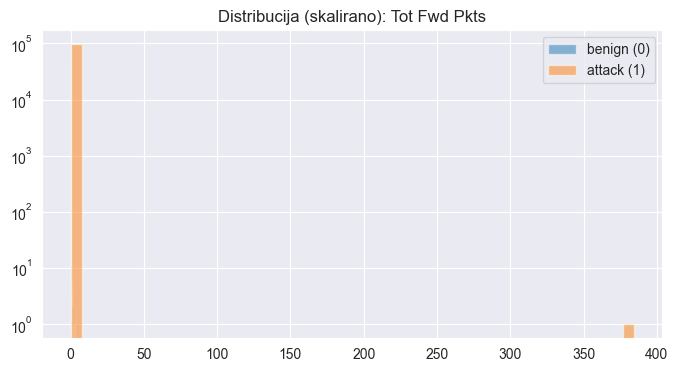

In [107]:
feature_to_check = 'Tot Fwd Pkts'
col_idx = list(X.columns).index(feature_to_check)

benign_vals = X_train[y_train.values == 0, col_idx]
attack_vals = X_train[y_train.values == 1, col_idx]

plt.figure(figsize=(8,4))
plt.hist(benign_vals, bins=50, alpha=0.5, label='benign (0)')
plt.hist(attack_vals, bins=50, alpha=0.5, label='attack (1)')
plt.legend()
plt.title(f'Distribucija (skalirano): {feature_to_check}')
plt.yscale('log')
plt.show()